In [1]:

# Luego importamos otras librerias que seguramente vamos a necesitar

import pandas as pd
import numpy as np
import re
import unicodedata
#from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df_train = pd.read_csv("train.csv")
data = df_train.copy()

## 1. Procesamiento de texto

Teniendo en cuenta que los textos crudos no son datos estructurados, se realiza NLP (natural languaje processing) para poder transformarlos en vectores y, de esta manera, permitir que los algoritmos de aprendizaje puedan usarlos.

Para esto, se utilizan representaciones dispersas (matrices dispersas) que permiten representar cada frase como un vector en un espacio vectorial semantico de dimensiones $\mathbb{R}^{|V|}$, donde |V| es el tamaño del vocabulario. Se hace uso del pipeline general definido para realizar este tipo de procesamiento: 
```text
Texto crudo
    ↓  Limpieza (lowercase, puntuación)
Texto normalizado
    ↓  Tokenización
Lista de tokens
    ↓  Stop words + Stemming
Tokens procesados
    ↓  Vectorización (BoW / TF-IDF)
Vector numérico ∈ ℝ^|V|
```

In [3]:
stop_words_es = set(stopwords.words('spanish'))

# Palabras relevantes que no queremos eliminar porque cambiarian la interpretación del modelo
palabras_relevantes = {"no", "nunca", "jamás", "sin", "ni", "tampoco",
"pero", "aunque","muy", "bastante", "demasiado", "más", "menos", "poco"}

stop_words_es -= palabras_relevantes

stemmer = SnowballStemmer('spanish')

def preprocesar_texto(texto):
    # A. Normalización: Convertir a minúsculas
    texto = texto.lower()
    
    # B. Normalización: Quitar signos de puntuación (deja solo letras y espacios)
    texto = re.sub(r'[^\w\s]', '', texto)
    
    # C. Tokenización: Separar por espacios
    tokens = texto.split()
    
    # D. Stopwords y Stemming: Filtrar palabras vacías y extraer la raíz
    tokens_procesados = [
        stemmer.stem(palabra) 
        for palabra in tokens 
        if palabra not in stop_words_es
    ]
    
    # E. Volver a unir en una sola cadena para el vectorizador
    return " ".join(tokens_procesados)



In [4]:
def separar_oraciones(texto):
    # Separacion del texto en oraciones
    oraciones = re.split(r'(?<=[.!?])\s+', texto.strip())
    return [o for o in oraciones if o.strip()]

def marcar_posicion(texto):
    # Separa en oraciones y marca cada token según su posición
    oraciones = separar_oraciones(texto)
    n = len(oraciones)
    tokens = []
    for i, oracion in enumerate(oraciones):
        if i == n - 1:
            prefijo = "L"   # última oración
        elif i == n - 2:
            prefijo = "P"   # penúltima
        else:
            prefijo = "E"   # el resto
        tokens += [f"{prefijo}_{tok}" for tok in preprocesar_texto(oracion).split()]
    return " ".join(tokens)

In [5]:
# 3. Aplicar el pipeline al DataFrame
df_train['text_posicion'] = df_train['text'].apply(marcar_posicion)

## 2. Representación del texto

In [6]:
# 4. Vectorizar (Bolsa de Palabras)
vec = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,      # suaviza palabras repetidas: usa 1 + log(tf)
    min_df=2,
    token_pattern=r'\S+'    # cada token separado por espacio cuenta entero, con su prefijo
)

#Vectorización completa de los textos limpios, generando una matriz dispersa donde cada fila representa un texto y cada columna representa un término (palabra o n-grama) del vocabulario generado por el vectorizador. Los valores en la matriz indican la frecuencia de cada término en cada texto.
#Esto es lo que usamos para ya entrenar el modelo que hagamos
X_train = vec.fit_transform(df_train['text_posicion'])
y_train = df_train['label']

## 3. Modelo 1: Regresión Logística

La Regresión Logística es un clasificador lineal que, para cada clase (negativo, neutral, positivo), aprende un peso por cada término del vocabulario. Para predecir, suma los pesos de los términos presentes en la reseña y convierte el resultado en probabilidades con la función softmax. La clase con mayor probabilidad es la predicción.

Se eligió porque:
- Funciona muy bien con representaciones dispersas y de alta dimensión como TF-IDF.
- Es interpretable: los pesos muestran qué términos empujan hacia cada clase (por ejemplo, `L_excelent` hacia positivo).
- Entrega probabilidades, útiles para analizar la confianza del modelo o para combinarlo con otros modelos.

Para estimar su desempeño en datos no vistos se usa **validación cruzada estratificada de 5 folds**: los datos se dividen en 5 partes con la misma proporción de clases; se entrena con 4 y se evalúa con la restante, rotando 5 veces. El accuracy final es el promedio.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Validación cruzada estratificada: 5 particiones que mantienen la proporción de clases.
# shuffle=True mezcla los datos antes de dividir y random_state=42 hace que la división sea replicable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Regresión Logística multiclase (negativo, neutral, positivo)
log_reg = LogisticRegression(
    C=10,            # Inverso de la regularización: C alto = menos regularización, el modelo se ajusta más a los datos.
                     # Con C=1 se obtiene ~86,4 % y con C=10 ~87,1 %
    max_iter=2000,   # Iteraciones máximas del optimizador; con tantas features necesita más de las 100 por defecto para converger
    random_state=42  # Semilla para que los resultados sean replicables
)

# Entrena y evalúa el modelo 5 veces, una por cada fold, y devuelve el accuracy de cada una
scores = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring='accuracy')

print("Accuracy por fold:", scores.round(4))
print(f"Accuracy promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")

Accuracy por fold: [0.8742 0.8717 0.8708 0.8696 0.87  ]
Accuracy promedio: 0.8713 (+/- 0.0016)


### Análisis de resultados por clase

El accuracy promedio no muestra en qué clases se equivoca el modelo. Para verlo se usa `cross_val_predict`, que devuelve la predicción de cada reseña hecha por el modelo del fold en el que esa reseña quedó como validación. Así se obtienen predicciones de las 12.000 reseñas sin que el modelo haya visto ninguna durante su entrenamiento.

Con esas predicciones se construyen:
- **Reporte de clasificación:** precisión, recall y F1 por clase.
- **Matriz de confusión:** cuántas reseñas de cada clase real fueron asignadas a cada clase predicha.

              precision    recall  f1-score   support

    negativo     0.8241    0.8219    0.8230      4212
     neutral     0.9774    0.9927    0.9850      3576
    positivo     0.8263    0.8174    0.8218      4212

    accuracy                         0.8712     12000
   macro avg     0.8759    0.8774    0.8766     12000
weighted avg     0.8705    0.8712    0.8709     12000



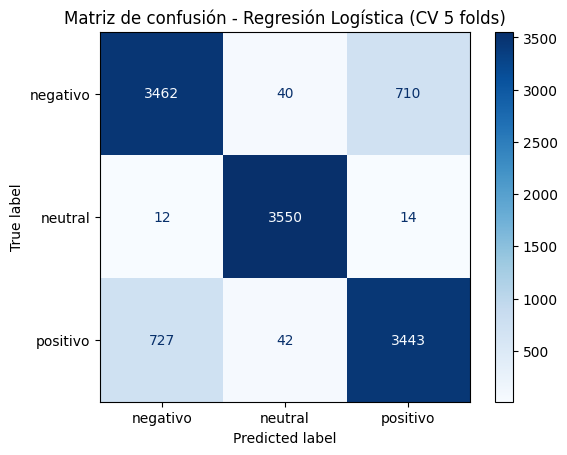

In [8]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Predicción de cada reseña con el modelo del fold donde quedó como validación
y_pred_cv = cross_val_predict(log_reg, X_train, y_train, cv=cv)

# Precisión, recall y F1 por clase
print(classification_report(y_train, y_pred_cv, digits=4))

# Matriz de confusión: filas = clase real, columnas = clase predicha
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_cv, cmap='Blues')
plt.title("Matriz de confusión - Regresión Logística (CV 5 folds)")
plt.show()

### Conclusiones del Modelo 1

La Regresión Logística con TF-IDF y marcas de posición alcanza un accuracy promedio de 87,13 % en validación cruzada, con una desviación de apenas ±0,16 % entre folds. El modelo es estable y no depende de una partición en particular.

El análisis por clase muestra un comportamiento muy desigual:

| Clase | Precisión | Recall | F1 |
| --- | --- | --- | --- |
| Neutral | 97,74 % | 99,27 % | 98,50 % |
| Negativo | 82,41 % | 82,19 % | 82,30 % |
| Positivo | 82,63 % | 81,74 % | 82,18 % |

- **Neutral se clasifica casi perfecto.** Estas reseñas solo describen aspectos logísticos (envío, color, tamaño, contenido de la caja) y no contienen términos de opinión, así que el modelo las separa con facilidad.
- **El problema está entre positivo y negativo.** De los 1.545 errores, 1.437 (93 %) son reseñas positivas clasificadas como negativas o viceversa. Son las reseñas que mezclan elogios y quejas, donde el sentimiento global depende del conector contrastivo ("aun así", "eso sí", "por otro lado") y de la parte que viene después.

In [ ]:

# 4. Generación de Predicciones para Kaggle


#Re-entrenar el modelo con el 100% de los datos de train
log_reg.fit(X_train, y_train)

#Cargar los archivos de evaluación y formato
df_eval = pd.read_csv("eval.csv")
df_sub = pd.read_csv("sample_submission.csv")

# Aplicar el mismo preprocesamiento a eval.csv
df_eval['text_posicion'] = df_eval['text'].apply(marcar_posicion)

# Vectorizar con .transform() (mantiene el vocabulario aprendido en train)
X_eval = vec.transform(df_eval['text_posicion'])

#Generar predicciones
predicciones = log_reg.predict(X_eval)

#Asignar los resultados a la columna 'answer'
df_sub['answer'] = predicciones

# Exportar
df_sub.to_csv("submission_logreg_v1_grupo18.csv", index=False)


¡Archivo 'submission_logreg_v1_grupo18.csv' listo para subir a Kaggle!
